## 1. Importing Library and Data

### 1.1 Importing Library

In [2]:
# Import Library
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from torchmetrics.classification import BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAUROC 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

### 1.2 Reading CSV to Dataframe

In [9]:
df = pd.read_csv('data/data2.csv')

### 1.3 Understanding the Data

In [ ]:
# Reading the First 5 Rows
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
# Determining the number of fraudulent transaction records
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
# Checking missing values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [12]:
# Checking data features's distribution
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
# Data shapes (Row, Column)
df.shape

(6362620, 11)

## 2. Data Processing and Feature Engineering

### 2.1 Dropping Irrelevant Features

In [6]:
# Dropping Irrelevant Features
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
for col in drop_cols:
    df.drop(columns=col, inplace=True)

The rationale for dropping these columns is that they do not contribute any meaningful statistical value to the model’s understanding or predictive capability.

### 2.2 Creating New Features

In [7]:
# Creating New Features
df['amountTxn'] = (df['oldbalanceOrg'] - df['newbalanceOrig'])

# Drop rows where amountTxn is not positive or oldbalanceOrg is zero
df = df[(df['amountTxn'] > 0) & (df['oldbalanceOrg'] > 0)]

# Creating Percentage of Transaction towards current balance
df['pcntTxn'] = (df['amountTxn'] / df['oldbalanceOrg']) * 100

This process consists of three key steps:
1. Transaction Amount Calculation - We generated the amountTxn (transaction amount) column by subtracting the new balance from the old balance. This calculation produces both positive and negative values, depending on the transaction direction.
2. Filtering Transactions - Negative transaction amounts indicate that the new balance exceeds the old balance, meaning funds were added to the account. Such transactions are excluded, as our focus is solely on fraudulent activities involving unauthorized fund withdrawals. Additionally, transactions where the origin account’s old balance is zero are removed, since it is logically impossible to withdraw funds from an empty account.
3. Creating Transaction Percentage Feature - We introduced a percentage transaction column, representing the transaction amount as a percentage of the old balance. Since fraudulent transactions often involve amounts close to 100% of the available balance, this feature may help the model better identify suspicious patterns.

### 2.3 Quick Data Visualization

########## THIS IS DF DATAFRAME ##########
THIS IS A GRAPH OF "STEP"


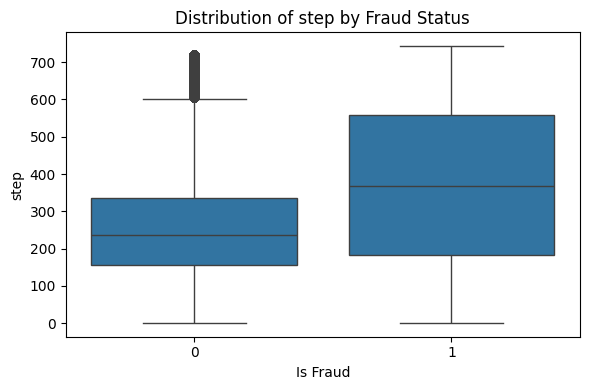

THIS IS A GRAPH OF "TYPE"


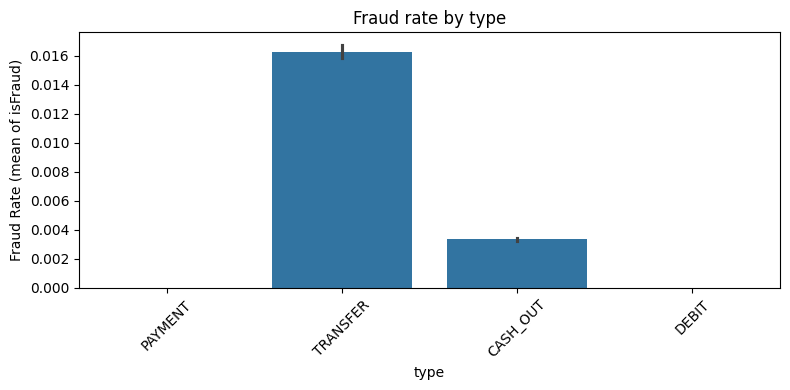

THIS IS A GRAPH OF "AMOUNT"


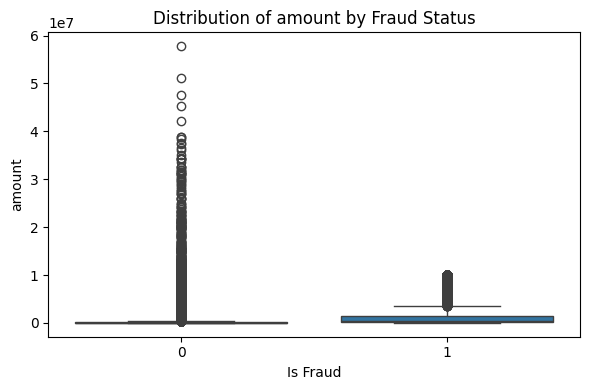

THIS IS A GRAPH OF "OLDBALANCEORG"


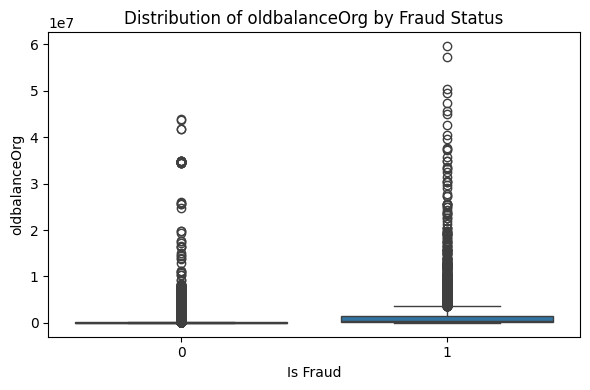

THIS IS A GRAPH OF "NEWBALANCEORIG"


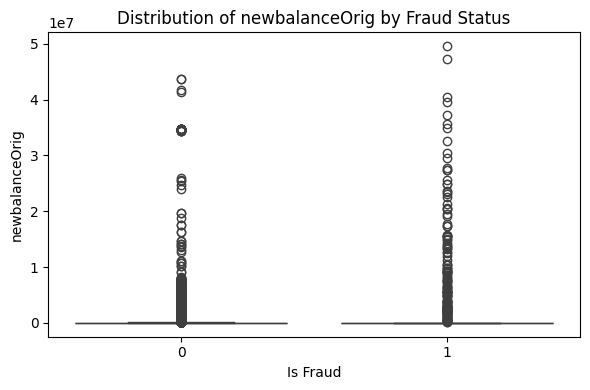

THIS IS A GRAPH OF "OLDBALANCEDEST"


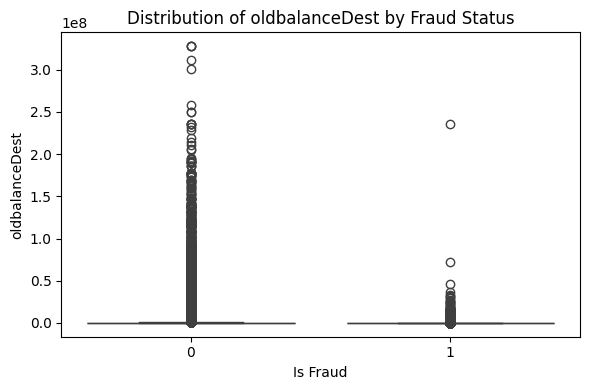

THIS IS A GRAPH OF "NEWBALANCEDEST"


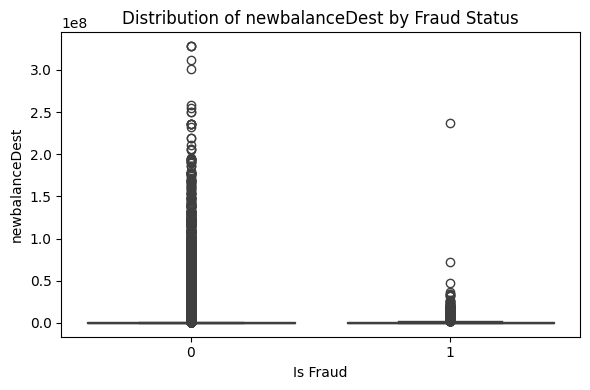

THIS IS A GRAPH OF "AMOUNTTXN"


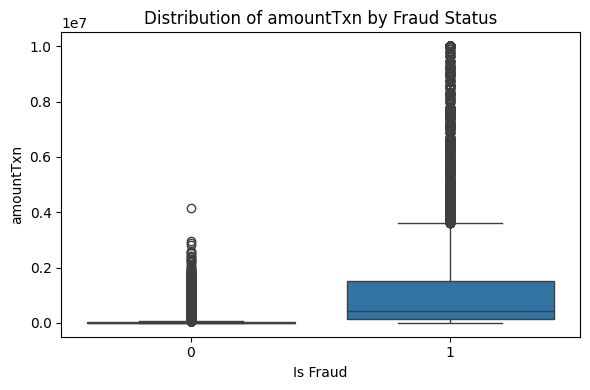

THIS IS A GRAPH OF "PCNTTXN"


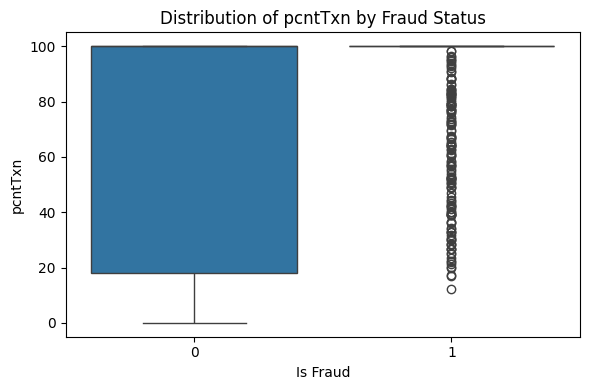

In [8]:
# Creating Visualization
def barplot_graph(feature, target, dfs, bins=None):
    data = dfs.copy()

    # If binning is requested
    if bins is not None:
        data['binned'] = pd.cut(data[feature], bins=bins)
        x_col = 'binned'
    else:
        x_col = feature

    plt.figure(figsize=(8, 4))
    sns.barplot(x=x_col, y=target, data=data, estimator='mean')
    plt.title(f'Fraud rate by {feature}')
    plt.ylabel('Fraud Rate (mean of isFraud)')
    plt.xlabel(feature if bins is None else f'{feature} (binned)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def boxplot_graph(feature, dfs, target='isFraud'):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target, y=feature, data=dfs)
    plt.title(f'Distribution of {feature} by Fraud Status')
    plt.xlabel('Is Fraud')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

# Apply logic
dataframes = [('df', df)] # ('df', df)
for name, dfs in dataframes:
    print(f'########## THIS IS {name.upper()} DATAFRAME ##########')
    for col in dfs.columns:
        nunique = dfs[col].nunique()
        
        if col == 'isFraud':  # skip target itself
            continue
        print(f'THIS IS A GRAPH OF "{col.upper()}"')
        if 1 < nunique < 9:
            barplot_graph(col, 'isFraud', dfs=dfs)
        elif 19 < nunique < 25:
            if dfs is df:
                barplot_graph(col, 'isFraud', dfs=dfs, bins=5)
            else:
                barplot_graph(col, 'isFraud', dfs=dfs)
        elif 100 < nunique < 177:
            barplot_graph(col, 'isFraud', dfs=dfs, bins=10)
        else:
            boxplot_graph(col, dfs=dfs)


### 2.4 Categorizing Data

In [ ]:
# Correcting Data Types
cat_cols = []
num_cols = []
columns = list(df.columns)
for col in columns:
    n_unique = df[col].nunique()
    if n_unique == 2:
        try:
            df[col] = df[col].astype(int)
        except ValueError:
            df[col] = df[col].astype('category').cat.codes
        num_cols.append(col)
    elif 2 < n_unique < 22:
        if not np.issubdtype(df[col].dtype, np.number): # Check if it is numerical columns
            cat_cols.append(col)
        else:
            num_cols.append(col)
    else:
        num_cols.append(col)
num_cols.remove('isFraud')

print(f'Categorical: {cat_cols}')
print(f'Numerical: {num_cols}')

Categorical: ['type']
Numerical: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'amountTxn', 'pcntTxn']


This step does not necessarily need to be long. However, the underlying logic can be applied to any dataset to efficiently categorize each feature into its corresponding type, such as categorical or numerical variables.

### 2.5 Turning Categorical Column into Integer

In [ ]:
# Changing categorical column into integer
for col in df.columns:
    if col in cat_cols:
        df[col] = df[col].astype('category').cat.codes
    else:
        continue

**Remember:** Machine learning models can only interpret numerical data. Therefore, any non-numerical values must be converted into numerical representations before training.

In [ ]:
# Checking How many is the fraud
df['isFraud'].value_counts()

isFraud
0    2866174
1       8156
Name: count, dtype: int64

## 3. Model Training

### 3.1 Deviding Data into X and y

In [ ]:
# Assigning X and y
y = df['isFraud']
X = df.drop('isFraud', axis=1)

The **X** variable represents all independent features, whereas **y** serves as the dependent (target) variable.

### 3.2 Data Splitting into Training and Testing

In [ ]:
# Splitting X and y into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

One of the most important steps in machine learning is dividing the data into training and testing sets. The purpose of this is to let the model learn patterns from the training data and then evaluate its ability to generalize by testing it on data it hasn’t seen before

### 3.3 Data Preprocessing and Modeling Pipeline

In [ ]:
# Preprocess numeric and categorical column
preprocessor = ColumnTransformer(
    transformers= [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ],
    remainder='drop'
)

# Creating the Data Pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

You can't miss this crucial step in our model training since it is the building block of it. This is how it goes:
1. We process our data using the `ColumnTransformer` class. Inside it, we transform every numerical feature from our numerical column list by standardizing them using `StandardScaler()`. The logic behind this function is subtracting the mean and dividing by the standard deviation so they will have mean = 0 and std = 1. This helps our Logistic Regression to converge faster and treat features equally.
2. Still in the same data preprocessing function, using `OneHotEncoder`, we turn our categorical features into a one-hot numeric array, creating binary columns for each category.
3. We create our data preprocessing pipeline, which combines our data preprocessor with our `LogisticRegression` model that will understand our data.

### 3.4 Model Training

In [ ]:
# Model Training
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The `pipeline.fit()` inserts our `X_train` and `y_train` variables to be processed by our pipeline that we have built from our previous step, which preprocesses our data using `StandardScaler()` for our numerical variables and `OneHotEncoding` for our categorical variables. Then, it understands the relationship between `X_train` and `y_train` using our `LogisticRegression()`.

## 4. First Prediction and Filter

### 4.1 Model Prediction

In [ ]:
# Model Prediction After Training
y_pred = pipeline.predict(X_test)

After we train our model, we test our trained model using `pipeline.predict()` and we pass in our `X_test` to create the prediction as `y_pred`.

### 4.2 Model Prediction's Performance

In [ ]:
# Checking Model Precision, Recall, F1-Score, and Accuracy
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    716544
           1       0.14      1.00      0.24      2039

    accuracy                           0.98    718583
   macro avg       0.57      0.99      0.62    718583
weighted avg       1.00      0.98      0.99    718583



Then, we compare our predictions, `y_pred`, with the true `y_test` values using the `classification_report()` function. The interpretation of our first model’s performance is as follows:
- Our model successfully detected all fraudulent transactions, as indicated by the recall for `isFraud` == 1 being 1.00.
- However, only 14% of those flagged transactions were actually fraudulent, as shown by the precision score of 0.14.
- In other words, the model identified all 8,156 fraudulent transactions by flagging approximately 58,267 transactions as fraud, meaning that around 50,111 legitimate transactions were incorrectly labeled as fraudulent.
- We certainly want to avoid falsely flagging legitimate customers as fraudsters, and this is where our second model comes into play.

In [ ]:
pipeline.score(X_test, y_test)

0.9822316976605346

## 5. Second Prediction and Filter
From the initially flagged fraudulent transactions, we extracted and re-evaluated the data using a PyTorch-based machine learning model to achieve a more accurate identification of fraudulent activities.

### 5.1 Extracting Previously Flagged Transaction Data

In [26]:
results = X_test.copy()
results['y_true'] = y_test.values
results['y_pred'] = y_pred

flagged = results[results['y_pred'] == 1]

Firstly, we take all of the transaction flagged as fraud by previous model and assigning them to the new `flagged` dataframe.

### 5.2 Configuring the Computing Device for Model Training

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### 5.3 Assigning Data to X and y

In [28]:
X_flagged = flagged.drop(columns=['y_pred', 'y_true'])
y_flagged = flagged['y_true']

Just like before, we seperate our X variables and y variable.

### 5.4 Second Data Splitting to Training and Testing Data

In [29]:
# Data Splitting
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_flagged, y_flagged, test_size=0.25, random_state=42, stratify=y_flagged
)

Then, we once again, split our data into training and testing data using `train_test_split`

### 5.5 Turning Dataframe into Tensor Data

In [30]:
# Convert to NumPY Array and then to Tensor
X_train2 = torch.from_numpy(X_train2.to_numpy(dtype='float32')).to(device)
y_train2 = torch.from_numpy(y_train2.to_numpy(dtype='float32')).to(device)
X_test2 = torch.from_numpy(X_test2.to_numpy(dtype='float32')).to(device)
y_test2 = torch.from_numpy(y_test2.to_numpy(dtype='float32')).to(device)

This is where the difference from the previous model begins. In this second model, we use a PyTorch-based machine learning model. However, this model only understands data that has been converted into **Tensor** type. To achieve this, we first convert our data into **NumPy** type, and then transform it into **Tensor** type following the sequence shown above.

### 5.6 Creating Machine Learning Model using Neural Network

In [ ]:
# Layer Variable
input_feature = X_train2.shape[1]
feature_1 = 128
feature_2 = feature_1 // 2
feature_3 = feature_2 // 2

# Constructing the Model
class FraudDetectorV4(nn.Module):
    def __init__(self):
        super().__init__()
        # Create Neural Network Layers
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=input_feature, out_features=feature_1),
            nn.ReLU(),
            nn.BatchNorm1d(feature_1),
            nn.Dropout(0.3),
            nn.Linear(in_features=feature_1, out_features=feature_2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(in_features=feature_2, out_features=feature_3),
            nn.ReLU(),
            nn.Linear(in_features=feature_3, out_features=1),
        )

    def forward(self, x):
        return self.layer_stack(x)
    
# Instantiate the model
model_4 = FraudDetectorV4().to(device)
main_model = model_4

This is our model-building process. In PyTorch, to create a model, we must define a class that inherits from the parent class `nn.Module` using `super().__init__()`. Inside nn.Sequential(), we then construct a stack of layers consisting of four linear layers (`nn.Linear()`), three non-linear activation layers (`nn.ReLU()`), two dropout layers (`nn.Dropout()`), and one batch normalization layer (`nn.BatchNorm1d()`).

**Note:** In PyTorch, nn.Module serves as the parent class used for nearly all machine learning model implementations.

### 5.7 Assigning Loss and Optimizer Function

In [ ]:
# Assign Loss Function & Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(main_model.parameters(), lr=0.1)

# Create Accuracy Function
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

Before we run our training loop for our model, we create several functions that will be used by our model to learn. These are the functions:
1. Loss Function (`BCEWithLogitsLoss`): Measures how far the model's prediction are from the true labels in binary classification. The smaller the value, the better the prediction.
2. Optimizer (`SGD` / Stochastic Gradient Descent): It adjust the model's weight step by step to reduce the loss, helping the model learn from mistakes.
3. Accuracy Fuction: It is a helper function to calculate the percentage of correct prediction out of all prediction. 

### 5.8 Model's Training Loop

In [34]:
torch.manual_seed(42)

# Set number of epochs
epochs = 400

### Create The Training Loop
for epoch in range(epochs):
    # Put model in training mode
    #main_model.train()

    # 1. Forward pass
    y_train_logits = main_model(X_train2).squeeze()
    y_train_pred = torch.round(torch.sigmoid(y_train_logits))

    # 2. Calculate Loss and Accuracy
    loss = loss_fn(y_train_logits, y_train2.squeeze().float())
    acc = accuracy_fn(y_train2.squeeze(), y_train_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing Loop
    # Put model in eval mode
    main_model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        y_test_logits = main_model(X_test2).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))

        # 2. Calculate Loss and Accuracy
        test_loss = loss_fn(y_test_logits, y_test2.squeeze().float())
        test_acc = accuracy_fn(y_test2.squeeze(), y_test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f}, Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.62589, Train Acc: 86.25% | Test Loss: 0.62401, Test Acc: 86.25%
Epoch: 10 | Train Loss: 0.44760, Train Acc: 92.35% | Test Loss: 0.44413, Test Acc: 92.65%
Epoch: 20 | Train Loss: 0.37879, Train Acc: 92.79% | Test Loss: 0.37109, Test Acc: 93.14%
Epoch: 30 | Train Loss: 0.33959, Train Acc: 93.06% | Test Loss: 0.33273, Test Acc: 93.25%
Epoch: 40 | Train Loss: 0.30807, Train Acc: 93.24% | Test Loss: 0.30279, Test Acc: 93.33%
Epoch: 50 | Train Loss: 0.28020, Train Acc: 93.42% | Test Loss: 0.27561, Test Acc: 93.46%
Epoch: 60 | Train Loss: 0.27482, Train Acc: 93.41% | Test Loss: 0.26761, Test Acc: 93.54%
Epoch: 70 | Train Loss: 0.25528, Train Acc: 93.56% | Test Loss: 0.25179, Test Acc: 93.54%
Epoch: 80 | Train Loss: 0.24183, Train Acc: 93.66% | Test Loss: 0.23926, Test Acc: 93.65%
Epoch: 90 | Train Loss: 0.23099, Train Acc: 93.69% | Test Loss: 0.22908, Test Acc: 93.70%
Epoch: 100 | Train Loss: 0.22231, Train Acc: 93.74% | Test Loss: 0.22107, Test Acc: 93.70%
Epoch: 110

This is the training loop process where our model learns from the data. Although it may appear complex, the underlying logic is quite straightforward. The flow of our training loop is as follows:
1. Set random seed: torch.manual_seed(42) ensures the training results are reproducible every time the code runs.
2. Define training duration: The model will train for 400 epochs, meaning it will go through the entire training data 400 times.
3. Forward pass: In each epoch, the model predicts outputs (y_train_logits), applies sigmoid to turn them into probabilities, and rounds them to 0 or 1 as predicted classes.
4. Calculate performance: The code computes the loss (how far predictions are from the truth) and accuracy (how many predictions are correct).
5. Reset gradients: optimizer.zero_grad() clears old gradients from the previous step to prevent accumulation.
6. Backpropagation: loss.backward() calculates how much each weight contributed to the error (gradient computation).
7. Update weights: optimizer.step() adjusts the model’s parameters slightly to reduce future loss — this is the learning process.
8. Evaluation phase: The model switches to evaluation mode (main_model.eval()) and predicts on test data without learning, measuring test loss and accuracy.
9. Progress tracking: Every 10 epochs, it prints training and testing loss and accuracy, allowing you to monitor how well the model learns and generalizes over time.

As shown in the terminal, our model improves with each training iteration, with its accuracy increasing from 86% to 94%.

### 5.9 Second Filter Prediction's Performance

In [35]:
with torch.no_grad():
    y_pred_2 = torch.round(torch.sigmoid(model_4(X_test2)))

print(classification_report(y_test2, y_pred_2))

              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97      3192
         1.0       0.91      0.63      0.74       509

    accuracy                           0.94      3701
   macro avg       0.93      0.81      0.85      3701
weighted avg       0.94      0.94      0.94      3701



Finally, we used our trained model to make predictions. We passed `X_test2` into the model to generate `y_pred_2`, then compared `y_pred_2` with the true labels `y_test2` using the `classification_report()` function.

Based on the results above, we can draw several conclusions:
1. In our test sample, 509 transactions were truly fraudulent.
2. The model correctly identified 63% of those 509 fraudulent transactions, approximately 321 true frauds, while only missing 37% of them.
3. Among all transactions predicted as fraudulent, 91% were indeed frauds, as indicated by the precision score of 0.91. This means that only about 9% of the flagged transactions were false positives.